# Assignment 1: Sampling and Reproducibility

The code at the end of this file explores contact tracing data about an outbreak of the flu, and demonstrates the dangers of incomplete and non-random samples. This assignment is modified from [Contact tracing can give a biased sample of COVID-19 cases](https://andrewwhitby.com/2020/11/24/contact-tracing-biased/) by Andrew Whitby.

Examine the code below. Identify all stages at which sampling is occurring in the model. Describe in words the sampling procedure, referencing the functions used, sample size, sampling frame, any underlying distributions involved. 


#### Stage 1:
`events = ['wedding'] * 200 + ['brunch'] * 800
ppl = pd.DataFrame({...})`

The sampling frame is defined as exactly 1000 attendees: 200 wedding, 800 brunch.
The distribution is fixed, not random.

#### Stage 2:
`infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
ppl.loc[infected_indices, 'infected'] = True`

Sample size: int(1000 * 0.10) = 100 infected people
Sampling frame: all 1000 attendees (both events combined)
Method: simple random sample without replacement of exactly 100 people.

#### Stage 3:
`ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS`

Sample size: sum(ppl['infected']) = 100 infected individuals 
Sampling frame: infected individuals only
Method: each infected person independently gets traced with probability TRACE_SUCCESS = 0.20
Underlying distribution: Bernoulli (p=0.20) for each infected person; total traced among infected is Binomial(100, 0.20).


#### Stage 4:
`event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True`

We are selecting events into a set based on whether they already have at least SECONDARY_TRACE_THRESHOLD = 2 traced infections.
Then, conditional on an event being selected, all infected people in that event become traced.
Sampling: Events with early traced cases are far more likely to become “fully traced,” which systematically biases traced cases toward the event type that is more likely to cross the threshold (weddings here, because they’re smaller and more clustered, so traced infections concentrate in fewer events).

#### Stage 5:
`results = [simulate_event(m) for m in range(1000)]`

Sample size: 1000 simulated (Monte Carlo repetition) outbreaks 
Sampling frame: the model’s implied stochastic process
Goal: approximate the distribution of outcomes (proportion of infections vs proportion of traced cases attributed to weddings).

Modify the number of repetitions in the simulation to 10 and 100 (from the original 1000). Run the script multiple times and observe the outputted graphs. Comment on the reproducibility of the results.

10 repetitions: histograms vary a lot from run-to-run and there is noticeably different red-vs-blue overlap each run.

100 repetitions: noticeably more stable than 10, but there are still changes between runs. The histogram shapes/overlap starts to settle; bin counts and can still vary from run to run.

1000 repetitions: much more stable. Run-to-run variation still exists, but visually the distributions look more similar.

Alter the code so that it is reproducible. Describe the changes you made to the code and how they affected the reproducibility of the script. The script needs to produce the same output when run multiple times.

Before: every call to np.random.choice and np.random.rand pulls fresh randomness from NumPy’s global RNG state → different outcomes each run.

After: all randomness comes from a Generator initialized with a fixed SEED → the sequence of random draws is identical each run → the dataframe and histogram are identical each run (for a given number of REPS).

## Code

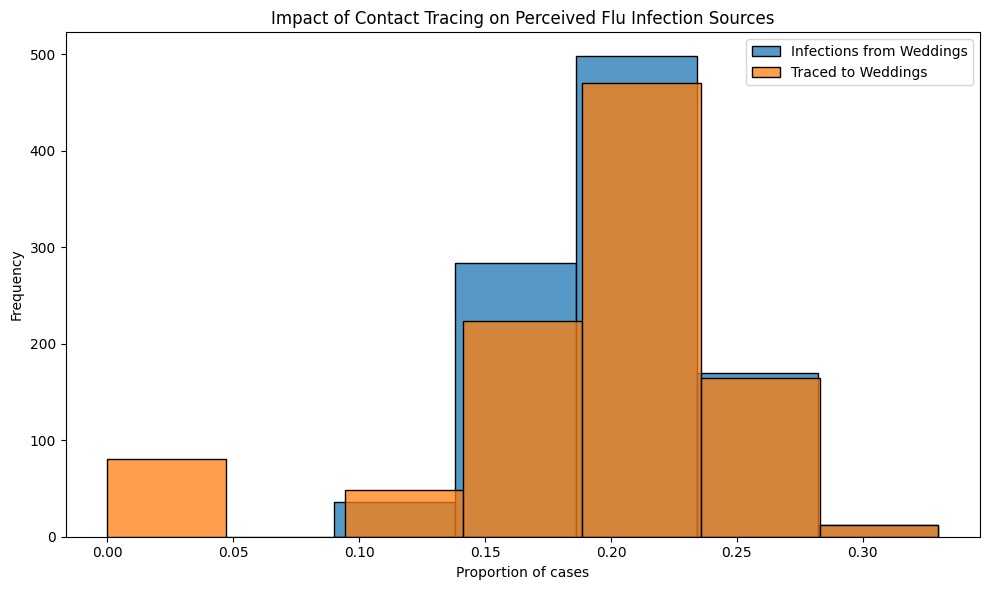

In [42]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2

# NEW: reproducibility controls
SEED = 12345          # pick any fixed integer
REPS = 1000           # set to 10, 100, or 1000 as needed

def simulate_event(rng):
    """
    Simulates the infection and tracing process for a series of events.
    Uses the provided RNG for reproducibility.
    """
    # Create DataFrame for people at events with initial infection and traced status
    events = ['wedding'] * 200 + ['brunch'] * 800
    ppl = pd.DataFrame({
        'event': events,
        'infected': False,
        'traced': pd.Series([pd.NA] * len(events), dtype="boolean")
    })

    # Infect a random subset of people (SRS without replacement; fixed number infected)
    n_infected = int(len(ppl) * ATTACK_RATE)
    infected_indices = rng.choice(ppl.index.to_numpy(), size=n_infected, replace=False)
    ppl.loc[infected_indices, 'infected'] = True

    # Primary contact tracing: Bernoulli(TRACE_SUCCESS) for each infected person
    infected_mask = ppl['infected'].to_numpy()
    ppl.loc[ppl['infected'], 'traced'] = rng.random(infected_mask.sum()) < TRACE_SUCCESS

    # Secondary contact tracing: if an event has >= threshold traced infections, trace all infected in that event
    event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
    events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
    ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True

    # Calculate proportions of infections and traces attributed to weddings
    ppl['event_type'] = ppl['event'].str[0]  # 'w' or 'b'

    wedding_infections = (ppl['infected'] & (ppl['event_type'] == 'w')).sum()
    brunch_infections   = (ppl['infected'] & (ppl['event_type'] == 'b')).sum()
    p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

    wedding_traces = (ppl['infected'] & (ppl['traced'] == True) & (ppl['event_type'] == 'w')).sum()
    brunch_traces  = (ppl['infected'] & (ppl['traced'] == True) & (ppl['event_type'] == 'b')).sum()
    denom = wedding_traces + brunch_traces
    p_wedding_traces = wedding_traces / denom if denom > 0 else np.nan  # defensive for rare zero-trace runs

    return p_wedding_infections, p_wedding_traces

# NEW: single RNG drives the whole experiment deterministically
rng = np.random.default_rng(SEED)

# Run the simulation REPS times
results = [simulate_event(rng) for _ in range(REPS)]
props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

# Plotting the results
plt.figure(figsize=(10, 6))
sns.histplot(props_df['Infections'], alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
sns.histplot(props_df['Traces'].dropna(), alpha=0.75, binwidth=0.05, kde=False, label='Traced to Weddings')
plt.xlabel("Proportion of cases")
plt.ylabel("Frequency")
plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.legend()
plt.tight_layout()
plt.show()


## Criteria

|Criteria|Complete|Incomplete|
|--------|----|----|
|Alteration of the code|The code changes made, made it reproducible.|The code is still not reproducible.|
|Description of changes|The author answered questions and explained the reasonings for the changes made well.|The author did not answer questions or explain the reasonings for the changes made well.|

## Submission Information
🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `23:59 - 02 February 2026`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This markdown file (`a1_sampling_and_reproducibility.ipynb`) should be populated with the code changed.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/sampling/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

#### Checklist:
- [ ] Create a branch called `assignment-1`.
- [ ] Ensure that the repository is public.
- [ ] Review [the PR description guidelines](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md#guidelines-for-pull-request-descriptions) and adhere to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via the help channel in Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
